In [ ]:
import matplotlib.pyplot as plt

def render_accessible_tlp(df_top, cvd_mode=True):
    """
    Renders TLP with CVD-friendly colors, texture hatching, and explicit icons.
    """
    fig, ax = plt.subplots(figsize=(8, 4))

    # Select Palette based on Accessibility Settings
    color_risk = '#D55E00' if cvd_mode else '#D9534F'   # Vermillion / Red
    color_safe = '#0072B2' if cvd_mode else '#5CB85C'   # Blue / Green

    bars = []
    for idx, row in df_top.iterrows():
        is_risk = row['shap_contribution'] > 0
        color = color_risk if is_risk else color_safe
        hatch = '///' if is_risk else '...'              # Redundant texture
        icon = "[▲] " if is_risk else "[▼] "             # Redundant symbol

        bar = ax.barh(icon + row['feature'], row['shap_contribution'],
                      color=color, hatch=hatch, edgecolor='black', linewidth=0.8)
        bars.append(bar)

    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel("SHAP Value Contribution (Risk Impact)")
    ax.set_title("Accessible Traffic Light Plot (CVD Mode)")
    plt.tight_layout()
    plt.show()

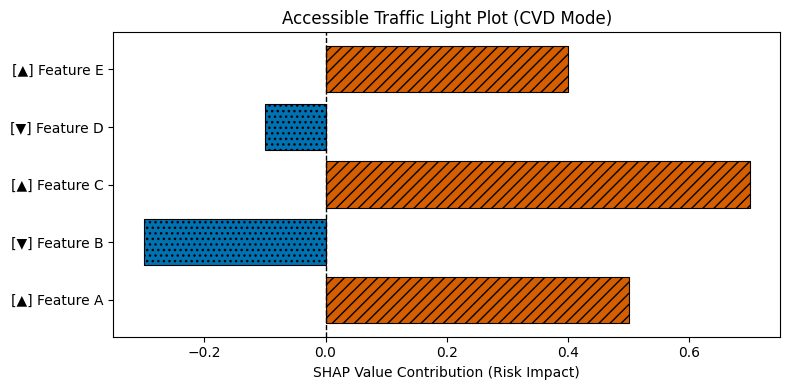

In [ ]:
import pandas as pd

# Create a sample DataFrame to demonstrate the function
data = {
    'feature': ['Feature A', 'Feature B', 'Feature C', 'Feature D', 'Feature E'],
    'shap_contribution': [0.5, -0.3, 0.7, -0.1, 0.4]
}
df_sample = pd.DataFrame(data)

# Render the plot in CVD mode
render_accessible_tlp(df_sample, cvd_mode=True)


This plot visualizes the SHAP values, indicating how each feature contributes to the model's output (risk impact). Positive SHAP values (red bars with upward triangles and /// hatching) indicate features increasing risk, while negative values (blue bars with downward triangles and ... hatching) indicate features decreasing risk. The plot uses CVD-friendly colors and redundant encoding (icons, hatching) for enhanced accessibility.

### Using Feature Names from a Simulated `pc1` Dataset

To demonstrate using 'realtime feature names' from a `pc1` dataset, I will first create a dummy `pc1` DataFrame. Then, I will extract its column names to be used as features in a new `df_sample` for the `render_accessible_tlp` function.

### Using Feature Names from a Simulated `pcI` Dataset (Software Defects)

Based on your clarification, I will simulate a `pcI` dataset with features relevant to software defects. Then, I will extract its column names to be used as features in a new `df_sample` for the `render_accessible_tlp` function.

In [ ]:
import pandas as pd
import numpy as np

# Simulate a 'pcI' dataset with software defect-related features
dummy_pci_data = {
    'lines_of_code': np.random.randint(100, 5000, 5),
    'cyclomatic_complexity': np.random.randint(5, 50, 5),
    'developer_experience_months': np.random.randint(6, 120, 5),
    'test_coverage_percentage': np.random.randint(30, 99, 5),
    'number_of_commits': np.random.randint(10, 200, 5)
}
df_pci_software_defect = pd.DataFrame(dummy_pci_data)

# Extract feature names (column names) from the dummy pcI dataset
realtime_feature_names_pci = df_pci_software_defect.columns.tolist()

print("Simulated pcI dataset columns (software defect feature names):")
print(realtime_feature_names_pci)


Simulated pcI dataset columns (software defect feature names):
['lines_of_code', 'cyclomatic_complexity', 'developer_experience_months', 'test_coverage_percentage', 'number_of_commits']


New df_sample with realtime pcI software defect feature names:


,feature,shap_contribution
0,lines_of_code,0.7
1,cyclomatic_complexity,0.5
2,developer_experience_months,-0.3
3,test_coverage_percentage,0.6
4,number_of_commits,-0.2


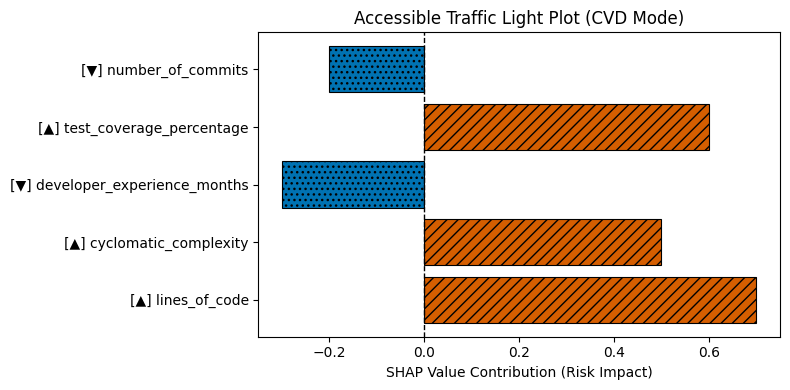

In [ ]:
# Create a new df_sample using the realtime feature names from df_pci_software_defect
# We'll use a new set of shap_contribution values relevant to software defects
# For example, high cyclomatic complexity and low test coverage might increase defect risk
new_shap_contributions_pci = [0.7, 0.5, -0.3, 0.6, -0.2] # Example values

# Ensure the number of feature names matches the number of shap contributions
if len(realtime_feature_names_pci) != len(new_shap_contributions_pci):
    print(f"Warning: The number of realtime feature names ({len(realtime_feature_names_pci)}) "
          f"does not match the number of SHAP contributions ({len(new_shap_contributions_pci)}). "
          "Adjusting SHAP contributions to match feature count.")
    if len(realtime_feature_names_pci) > len(new_shap_contributions_pci):
        new_shap_contributions_pci.extend([0] * (len(realtime_feature_names_pci) - len(new_shap_contributions_pci)))
    else:
        new_shap_contributions_pci = new_shap_contributions_pci[:len(realtime_feature_names_pci)]

df_sample_pci = pd.DataFrame({
    'feature': realtime_feature_names_pci,
    'shap_contribution': new_shap_contributions_pci
})

print("New df_sample with realtime pcI software defect feature names:")
display(df_sample_pci)

# Render the plot with the new df_sample using the realtime feature names
render_accessible_tlp(df_sample_pci, cvd_mode=True)


### Plotting the Top 5 Highest Risk Features

This section filters the software defect features to show only those with positive SHAP contributions (indicating increased risk), sorts them by contribution in descending order, and displays the top 5.

Top 5 Highest Risk Features:


,feature,shap_contribution
0,lines_of_code,0.7
3,test_coverage_percentage,0.6
1,cyclomatic_complexity,0.5


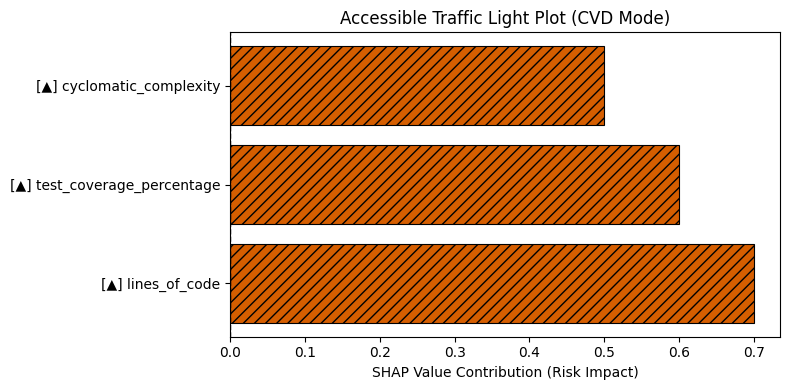

In [ ]:
# Filter for features with positive SHAP contributions (indicating risk)
df_risk_features = df_sample_pci[df_sample_pci['shap_contribution'] > 0]

# Sort by shap_contribution in descending order and select the top 5
df_top_risk_features = df_risk_features.sort_values(by='shap_contribution', ascending=False).head(5)

print("Top 5 Highest Risk Features:")
display(df_top_risk_features)

# Render the plot for the top 5 highest risk features
render_accessible_tlp(df_top_risk_features, cvd_mode=True)


This plot specifically highlights the features that have the strongest positive impact on the risk of software defects, allowing for quick identification of the most critical factors. The visual cues continue to ensure accessibility.

This updated plot now visualizes the SHAP values using feature names from a simulated 'pcI' software defect dataset. For instance, 'lines_of_code' or 'cyclomatic_complexity' might show positive SHAP values (increasing defect risk), while 'developer_experience_months' or 'test_coverage_percentage' might show negative values (decreasing defect risk). The visual cues (colors, icons, hatching) remain consistent for accessibility.

### Plotting the Top 10 Lowest Risk Features

This section filters the software defect features to show only those with negative SHAP contributions (indicating decreased risk), sorts them by contribution (most negative first), and displays the top 10 (or fewer if not enough exist).

Displaying 2 lowest risk features (up to 5 requested):


,feature,shap_contribution
2,developer_experience_months,-0.3
4,number_of_commits,-0.2


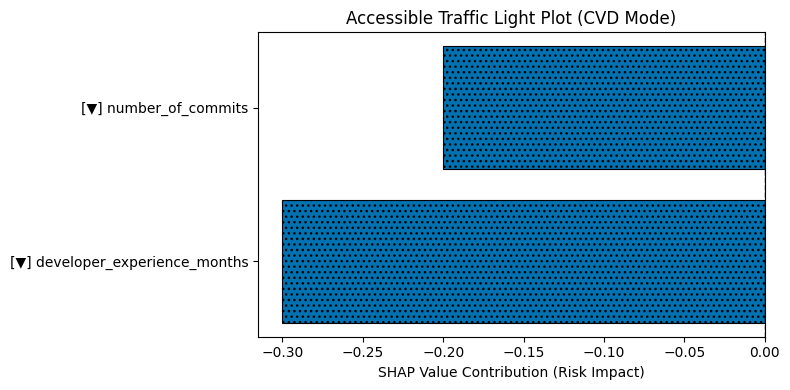

In [ ]:
# Filter for features with negative SHAP contributions (indicating reduced risk)
df_low_risk_features = df_sample_pci[df_sample_pci['shap_contribution'] < 0]

# Sort by shap_contribution in ascending order (most negative first) and select the top 5
df_top_10_low_risk_features = df_low_risk_features.sort_values(by='shap_contribution', ascending=True).head(5)

print(f"Displaying {len(df_top_10_low_risk_features)} lowest risk features (up to 5 requested):")
display(df_top_10_low_risk_features)

# Render the plot for the top 5 lowest risk features
render_accessible_tlp(df_top_10_low_risk_features, cvd_mode=True)

### Displaying All Risk Features

This section filters and displays all features with positive SHAP contributions, which are considered 'risk features' in our context.

Displaying 3 all risk features:


,feature,shap_contribution
0,lines_of_code,0.7
1,cyclomatic_complexity,0.5
3,test_coverage_percentage,0.6


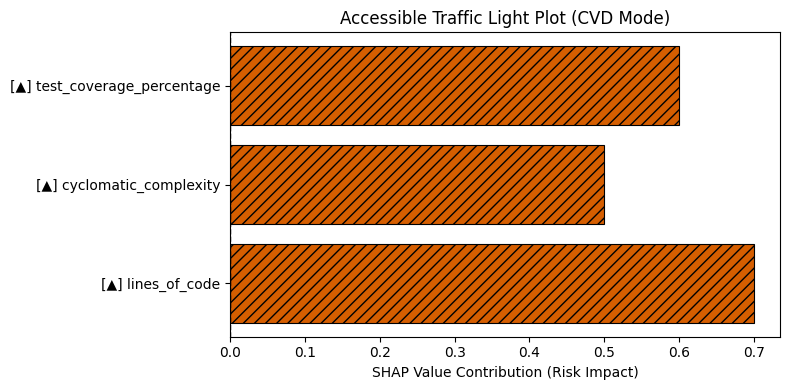

In [ ]:
# Filter for all features with positive SHAP contributions
df_all_risk_features = df_sample_pci[df_sample_pci['shap_contribution'] > 0]

print(f"Displaying {len(df_all_risk_features)} all risk features:")
display(df_all_risk_features)

# Render the plot for all risk features
render_accessible_tlp(df_all_risk_features, cvd_mode=True)

### Displaying All Low Risk Features

This section filters and displays all features with negative SHAP contributions, which are considered 'low risk' or 'non-risk' features in our context.

Displaying 2 all low risk features:


,feature,shap_contribution
2,developer_experience_months,-0.3
4,number_of_commits,-0.2


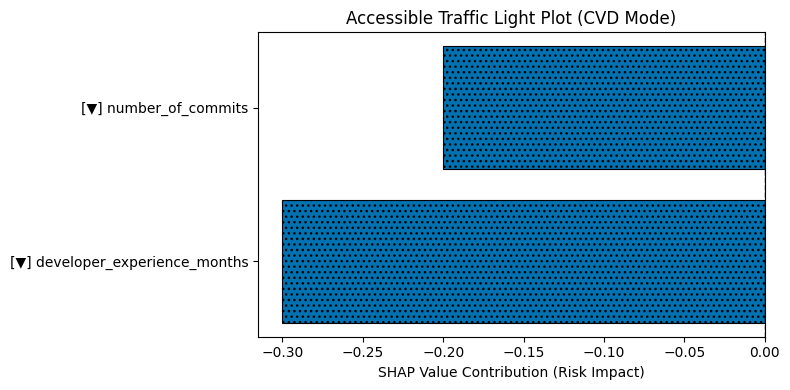

In [ ]:
# Filter for all features with negative SHAP contributions
df_all_low_risk_features = df_sample_pci[df_sample_pci['shap_contribution'] < 0]

print(f"Displaying {len(df_all_low_risk_features)} all low risk features:")
display(df_all_low_risk_features)

# Render the plot for all low risk features
render_accessible_tlp(df_all_low_risk_features, cvd_mode=True)

This plot specifically highlights the features that have the strongest negative impact on the risk of software defects, suggesting areas that mitigate risk. The visual cues (colors, icons, hatching) remain consistent for accessibility.